# Gate B3 — two-regime IMM для переходных режимов

## tl;dr

Gate B3 выполнен по заранее зафиксированному протоколу только на 911 train- и 130 validation-origins. B1, B5 и B6 прочитаны как неизменяемые prediction rows Gate B2; они не переобучались. Текущий T1 test не загружался.

`B7_two_regime_imm` выбрал `q_stable=0.5`, `q_transition=200`, `p_stable_stay=0.99`, `p_transition_stay=0.75`. Temporal MAE снизилась до **6.545 мм/год** против **7.454** у B6. Accelerating MAE стала **12.878** против **15.900** у B1.

Строгий screening всё же не пройден: `accelerating + volatile_or_gap` улучшен против B1 только на **3.3%** вместо 10%, volatile/gap MAE хуже B1, а leave-zone degradation к собственному temporal B7 равен **7.9%** при лимите 5%. 95% coverage равен **0.962**.

Итог — сильный новый comparator и частично подтверждённая структурная гипотеза, но статус остаётся `validation_recorded`. Финальный вывод требует нового future/external holdout.

## Context & Methods

Узкая гипотеза Gate B3: два динамических режима должны исправить известную accelerating/volatile transition error B6 и оставить temporal/spatial performance устойчивой. До outer-run были заморожены архитектура, сетка из 16 вариантов, train-only selection objective и девять критериев screening.

Оба режима используют состояние `[settlement, velocity, acceleration]`. Stable regime имеет сильное затухание acceleration и малый jerk noise; transition regime — почти сохраняющуюся acceleration и высокий jerk noise. Standard IMM смешивает состояния по Markov matrix и обновляет regime probabilities по причинным innovations settlement, uncertainty-derived last-rate и origin-known recent-acceleration.

В каждом outer fold параметры выбираются на трёх expanding-window inner folds. Objective — 50% normalized overall MAE и 50% normalized MAE на `accelerating + volatile_or_gap`, обе относительно B1 на тех же inner validation rows. Thresholds proxy fit только на inner train.

### Контрольные границы

- 1 temporal, 5 rolling-origin, 14 leave-profile-out и 4 leave-zone-out folds идентичны Gate B2;
- B1/B5/B6 prediction rows защищены SHA-256 и не пересчитываются;
- интервалы калибруются по 292 nested OOF origins только из train;
- причинная история обрезается по current_date каждого origin;
- model-facing test loader отсутствует;
- пустой held-out group и его CSV-представление NA примирены отдельным audit-adapter без изменения model outputs.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

root = Path.cwd().resolve()
while not (root / 'pyproject.toml').is_file():
    if root.parent == root:
        raise RuntimeError('Repository root not found')
    root = root.parent

artifact_dir = root / 'artifacts' / 'model_selection' / 't1_b3_v1'
report = json.loads((artifact_dir / 'gate_b3_report.json').read_text(encoding='utf-8'))
validation_report = json.loads((artifact_dir / 'validation_report.json').read_text(encoding='utf-8'))
reconciliation = json.loads((artifact_dir / 'audit_reconciliation.json').read_text(encoding='utf-8'))
candidate = json.loads((artifact_dir / 'development_candidate.json').read_text(encoding='utf-8'))
holdout_policy = yaml.safe_load((root / 'configs' / 'final_holdout_v2.yaml').read_text(encoding='utf-8'))
folds = pd.read_csv(artifact_dir / 'fold_contracts.csv')
tuning = pd.read_csv(artifact_dir / 'imm_tuning.csv')
aggregate = pd.read_csv(artifact_dir / 'aggregate_metrics.csv')
fold_metrics = pd.read_csv(artifact_dir / 'fold_metrics.csv')
transition = pd.read_csv(artifact_dir / 'transition_metrics.csv')
problem = pd.read_csv(artifact_dir / 'problem_transition_metrics.csv')
regimes = pd.read_csv(artifact_dir / 'regime_summary.csv')
intervals = pd.read_csv(artifact_dir / 'interval_metrics.csv')

pd.set_option('display.max_columns', 30)
{
    'candidate_id': candidate['candidate_id'],
    'candidate_status': candidate['status'],
    'screening_passed': candidate['screening_passed'],
    'current_t1_test_used': candidate['current_t1_test_used'],
    'final_holdout_status': holdout_policy['status'],
    'machine_validation': validation_report['summary'],
    'audit_model_outputs_changed': reconciliation['model_outputs_changed'],
}

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\SUKUNA-AI\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


{'candidate_id': 't1-b3-v1-15208e3b1684',
 'candidate_status': 'validation_recorded',
 'screening_passed': False,
 'current_t1_test_used': False,
 'final_holdout_status': 'PENDING_DATA',
 'machine_validation': {'checks': 64, 'failed': 0},
 'audit_model_outputs_changed': False}

## Data

In [2]:
pd.DataFrame([
    {
        'split': 'train',
        'rows': report['data']['train_rows'],
        'target_date_max': report['data']['train_target_date_max'],
        'sample_ids_sha256': report['data']['train_sample_ids_sha256'],
        'role': 'fit + nested tuning + OOF calibration',
    },
    {
        'split': 'validation',
        'rows': report['data']['validation_rows'],
        'target_date_max': report['data']['validation_target_date_max'],
        'sample_ids_sha256': report['data']['validation_sample_ids_sha256'],
        'role': 'outer development evidence',
    },
])

,split,rows,target_date_max,sample_ids_sha256,role
0,train,911,2023-11-07,2cd9ef9d27536d6d4e63ef0a56ad51002823d1306ff7c3...,fit + nested tuning + OOF calibration
1,validation,130,2024-09-03,f72ce0a50c16bccca3ca87df4f4a7465b4d9eca2933e0d...,outer development evidence


In [3]:
fold_summary = folds.groupby('design').agg(
    folds=('fold_id', 'nunique'),
    min_train_rows=('train_rows', 'min'),
    max_train_rows=('train_rows', 'max'),
    validation_rows=('validation_rows', 'sum'),
)
assert (pd.to_datetime(folds['train_target_date_max']) < pd.to_datetime(folds['validation_target_date_min'])).all()
assert (pd.to_datetime(tuning['train_target_date_max']) < pd.to_datetime(tuning['validation_target_date_min'])).all()
assert tuning.groupby('tuning_context')['candidate_key'].nunique().eq(16).all()
fold_summary

,folds,min_train_rows,max_train_rows,validation_rows
design,,,,
leave_profile_out,14,824,867,130
leave_zone_out,4,489,829,130
rolling_origin,5,823,1027,218
temporal_holdout,1,911,911,130


In [4]:
selected_by_context = (
    tuning.loc[tuning['selected'].astype(bool), ['tuning_context', 'candidate_key']]
    .drop_duplicates()
)
selected_by_context['candidate_key'].value_counts().rename('selected_contexts').to_frame()

,selected_contexts
candidate_key,
qs=0.5|qt=200|ps=0.99|pt=0.75,23
qs=2|qt=200|ps=0.99|pt=0.75,3
qs=0.5|qt=200|ps=0.97|pt=0.75,1
qs=2|qt=200|ps=0.97|pt=0.75,1
qs=0.5|qt=50|ps=0.97|pt=0.75,1


## Results

In [5]:
model_order = [
    'B1_persistence_last_rate',
    'B5_fixed_kalman',
    'B6_adaptive_kalman',
    'B7_two_regime_imm',
]
mae_table = aggregate.pivot(index='model_id', columns='design', values='mae').loc[model_order]
mae_table.round(3)

design,leave_profile_out,leave_zone_out,rolling_origin,temporal_holdout
model_id,,,,
B1_persistence_last_rate,7.311,7.311,6.824,7.311
B5_fixed_kalman,8.036,8.036,7.696,8.036
B6_adaptive_kalman,7.311,8.405,6.959,7.454
B7_two_regime_imm,6.573,7.064,6.331,6.545


In [6]:
screening = pd.DataFrame([
    {'criterion': name, 'passed': passed}
    for name, passed in report['screening']['checks'].items()
])
screening

,criterion,passed
0,accelerating_vs_b1,True
1,coverage_95,True
2,leave_profile_degradation,True
3,leave_zone_degradation,False
4,leave_zone_vs_b1,True
5,problem_transition_vs_b1,False
6,problem_transition_vs_b6,True
7,temporal_vs_b6,True
8,volatile_or_gap_vs_b1,False


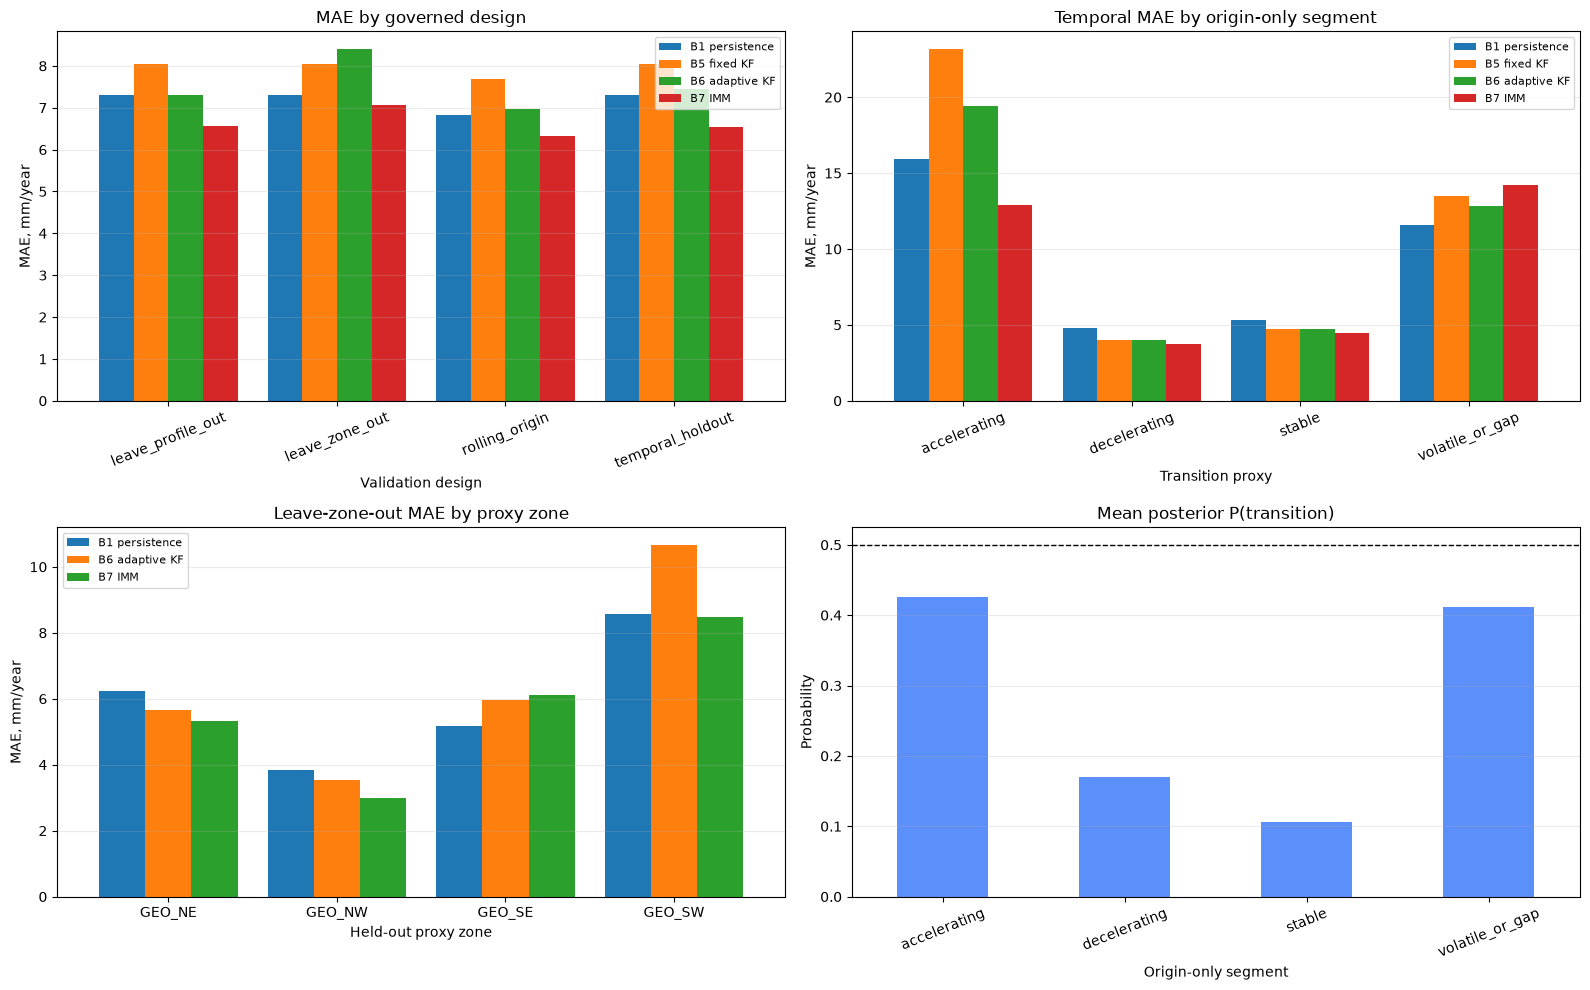

In [7]:
labels = {
    'B1_persistence_last_rate': 'B1 persistence',
    'B5_fixed_kalman': 'B5 fixed KF',
    'B6_adaptive_kalman': 'B6 adaptive KF',
    'B7_two_regime_imm': 'B7 IMM',
}
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

overall_plot = mae_table.rename(index=labels).T
overall_plot.plot(kind='bar', ax=axes[0, 0], width=0.82)
axes[0, 0].set_title('MAE by governed design')
axes[0, 0].set_ylabel('MAE, mm/year')
axes[0, 0].set_xlabel('Validation design')
axes[0, 0].tick_params(axis='x', rotation=22)
axes[0, 0].grid(axis='y', alpha=0.25)

temporal_transition = transition.loc[
    transition['design'].eq('temporal_holdout')
    & transition['scope'].eq('mechanism')
].pivot(index='segment', columns='model_id', values='mae')[model_order].rename(columns=labels)
temporal_transition.plot(kind='bar', ax=axes[0, 1], width=0.82)
axes[0, 1].set_title('Temporal MAE by origin-only segment')
axes[0, 1].set_ylabel('MAE, mm/year')
axes[0, 1].set_xlabel('Transition proxy')
axes[0, 1].tick_params(axis='x', rotation=22)
axes[0, 1].grid(axis='y', alpha=0.25)

zone_models = ['B1_persistence_last_rate', 'B6_adaptive_kalman', 'B7_two_regime_imm']
zone = fold_metrics.loc[
    fold_metrics['design'].eq('leave_zone_out')
    & fold_metrics['model_id'].isin(zone_models)
].pivot(index='held_out_group', columns='model_id', values='mae')[zone_models].rename(columns=labels)
zone.plot(kind='bar', ax=axes[1, 0], width=0.82)
axes[1, 0].set_title('Leave-zone-out MAE by proxy zone')
axes[1, 0].set_ylabel('MAE, mm/year')
axes[1, 0].set_xlabel('Held-out proxy zone')
axes[1, 0].tick_params(axis='x', rotation=0)
axes[1, 0].grid(axis='y', alpha=0.25)

regime_temporal = regimes.loc[regimes['design'].eq('temporal_holdout')].set_index('transition_segment')
regime_temporal['transition_probability_mean'].plot(kind='bar', ax=axes[1, 1], color='#5B8FF9')
axes[1, 1].axhline(0.5, linestyle='--', color='black', linewidth=1)
axes[1, 1].set_title('Mean posterior P(transition)')
axes[1, 1].set_ylabel('Probability')
axes[1, 1].set_xlabel('Origin-only segment')
axes[1, 1].tick_params(axis='x', rotation=22)
axes[1, 1].grid(axis='y', alpha=0.25)

for ax in axes.flat[:3]:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Transition-specific evidence

In [8]:
transition.loc[
    transition['design'].eq('temporal_holdout')
    & transition['scope'].isin(['stable_vs_transition', 'mechanism']),
    ['model_id', 'scope', 'segment', 'rows', 'points', 'profiles', 'mae', 'improvement_vs_b1_percent'],
].round(3)

,model_id,scope,segment,rows,points,profiles,mae,improvement_vs_b1_percent
88,B7_two_regime_imm,mechanism,accelerating,17,14,5,12.878,19.003
89,B1_persistence_last_rate,mechanism,accelerating,17,14,5,15.900,0.000
90,B6_adaptive_kalman,mechanism,accelerating,17,14,5,19.406,-22.052
91,B5_fixed_kalman,mechanism,accelerating,17,14,5,23.178,-45.775
92,B7_two_regime_imm,mechanism,decelerating,11,11,4,3.720,21.949
93,B6_adaptive_kalman,mechanism,decelerating,11,11,4,4.014,15.765
94,B5_fixed_kalman,mechanism,decelerating,11,11,4,4.035,15.333
95,B1_persistence_last_rate,mechanism,decelerating,11,11,4,4.766,0.000
96,B7_two_regime_imm,mechanism,stable,88,75,14,4.453,15.834
97,B6_adaptive_kalman,mechanism,stable,88,75,14,4.716,10.852


In [9]:
problem.loc[
    problem['design'].eq('temporal_holdout'),
    ['model_id', 'rows', 'points', 'profiles', 'mae', 'improvement_vs_b1_percent', 'improvement_vs_b6_percent'],
].round(3)

,model_id,rows,points,profiles,mae,improvement_vs_b1_percent,improvement_vs_b6_percent
12,B7_two_regime_imm,31,23,9,13.487,3.319,17.985
13,B1_persistence_last_rate,31,23,9,13.950,0.000,15.170
14,B6_adaptive_kalman,31,23,9,16.445,-17.883,0.000
15,B5_fixed_kalman,31,23,9,18.794,-34.727,-14.289


### Regime and leave-zone diagnostics

In [10]:
regimes.loc[
    regimes['design'].eq('temporal_holdout'),
    [
        'transition_segment', 'rows', 'transition_probability_mean',
        'transition_probability_median', 'transition_probability_q90',
        'transition_probability_ge_0_5_rate', 'mae',
    ],
].round(3)

,transition_segment,rows,transition_probability_mean,transition_probability_median,transition_probability_q90,transition_probability_ge_0_5_rate,mae
12,accelerating,17,0.425,0.412,1.000,0.471,12.878
13,decelerating,11,0.170,0.079,0.189,0.091,3.720
14,stable,88,0.107,0.035,0.326,0.045,4.453
15,volatile_or_gap,14,0.412,0.284,0.944,0.429,14.226


In [11]:
zone.round(3)

model_id,B1 persistence,B6 adaptive KF,B7 IMM
held_out_group,,,
GEO_NE,6.236,5.644,5.335
GEO_NW,3.845,3.548,2.995
GEO_SE,5.169,5.955,6.128
GEO_SW,8.570,10.667,8.487


### Interval calibration and machine QA

In [12]:
intervals.round(3)

,coverage_nominal,rows,coverage_empirical,coverage_gap,mean_width_mm_y,median_width_mm_y,mean_interval_score,qhat
0,0.80,130,0.885,0.085,20.249,18.195,34.920,2.165
1,0.90,130,0.923,0.023,30.206,27.141,50.254,3.230
2,0.95,130,0.962,0.012,47.618,42.787,67.632,5.092


In [13]:
assert validation_report['status'] == 'PASS'
assert validation_report['summary'] == {'checks': 64, 'failed': 0}
assert reconciliation['model_outputs_changed'] is False
assert reconciliation['authoritative_validation_failed'] == 0
assert report['test_data_loaded'] is False
assert report['test_phase_available'] is False
assert candidate['current_t1_test_used'] is False
assert candidate['eligible_for_final_claim'] is False
assert holdout_policy['status'] == 'PENDING_DATA'
{
    'independent_checks': validation_report['summary'],
    'assessment': validation_report['overall_assessment'],
    'protected_predecessors': 12,
    'comparators_refit': False,
    'model_outputs_changed_by_audit': reconciliation['model_outputs_changed'],
}

{'independent_checks': {'checks': 64, 'failed': 0},
 'assessment': 'Share with caveats',
 'protected_predecessors': 12,
 'comparators_refit': False,
 'model_outputs_changed_by_audit': False}

## Takeaways

1. **B7 — новый сильнейший development comparator.** Он снижает общую MAE относительно B1/B5/B6 во всех четырёх governed designs; temporal улучшение против B6 равно 12.19%.
2. **Accelerating-гипотеза подтверждена.** На 17 accelerating origins B7 лучше B1 на 19.00% и B6 на 33.64%; stable и decelerating performance также улучшились.
3. **Volatile/gap-гипотеза не подтверждена.** На 14 неоднородных volatile-or-gap origins B7 хуже B1 на 22.83%. Поэтому заранее заданное объединение problem transitions улучшено против B1 только на 3.32%, а не на требуемые 10%.
4. **Spatial stability улучшилась, но строгий gap остался.** Leave-zone MAE B7 лучше B1 на 3.37% и B6 на 15.95%; всё же собственный LZO-vs-temporal degradation равен 7.93% при лимите 5%. Основной residual failure — GEO_SE.
5. **Интервальная проверка проходит.** 95% empirical coverage 0.962 находится в коридоре 0.90–0.97, но средняя ширина 47.62 мм/год остаётся большой.
6. **Governance-решение однозначно.** Screening в целом не пройден, candidate status — `validation_recorded`, current test недопустим. Параметры B7 нельзя менять по этому validation; финальная проверка требует нового future/external holdout.